# IEEE-CIS Fraud Detection — Exploratory Data Analysis

Class balance, amount distributions, missingness, and `TransactionDT` coverage
(Phase A, PROJECT_SPEC.md Section 8).

**Provenance is printed in the banner below.** This notebook auto-detects the data
source: it uses the real competition data if present under `data/`, otherwise the
schema-identical **synthetic fixture** (SPEC Section 10). When the outputs read
`SYNTHETIC`, the charts are illustrative of structure only — re-run after
`uv run python -m pipeline.fetch_data` to regenerate this notebook on real data.

In [1]:
import sys, pathlib

# Make the repo importable regardless of the execution working directory.
_root = pathlib.Path.cwd()
while not (_root / "pyproject.toml").exists() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

from pipeline import data, features, schema

ds = data.load_dataset("auto")
df = ds.frame
PROV = ds.provenance.upper()
banner = f"DATA PROVENANCE: {PROV}"
if not ds.is_real:
    banner += "  —  synthetic fixture; illustrative structure only, NOT results."
print("=" * len(banner))
print(banner)
print("=" * len(banner))
print(f"rows: {len(df):,}   columns: {df.shape[1]}   fraud rate: {df[schema.TARGET].mean():.4%}")

DATA PROVENANCE: SYNTHETIC  —  synthetic fixture; illustrative structure only, NOT results.
rows: 5,000   columns: 434   fraud rate: 3.5000%


## 1. Class balance
Fraud is rare — the central modelling and decision challenge.

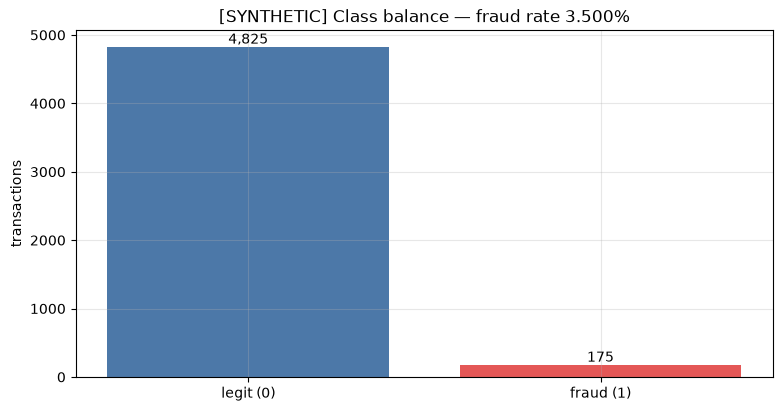

,count,fraction
isFraud,,
0,4825,0.965
1,175,0.035


In [2]:
counts = df[schema.TARGET].value_counts().sort_index()
rate = df[schema.TARGET].mean()
fig, ax = plt.subplots()
bars = ax.bar(["legit (0)", "fraud (1)"], counts.values, color=["#4c78a8", "#e45756"])
ax.set_ylabel("transactions")
ax.set_title(f"[{PROV}] Class balance — fraud rate {rate:.3%}")
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}", ha="center", va="bottom")
plt.show()
counts.to_frame("count").assign(fraction=lambda d: (d["count"] / d["count"].sum()).round(4))

## 2. Transaction amount distribution
Heavy-tailed; compared on a log axis for fraud vs legit.

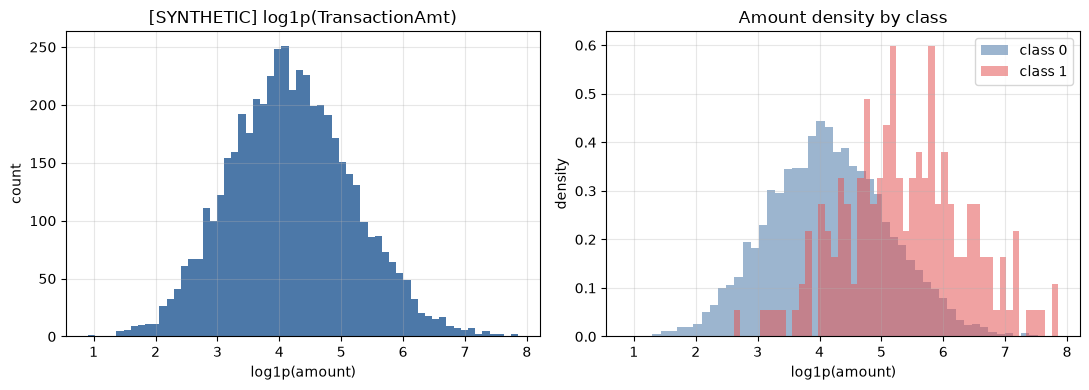

,mean,50%,max
isFraud,,,
0,101.88,60.69,1849.06
1,354.23,199.54,2593.47


In [3]:
amt = df[schema.AMT_COL]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(np.log1p(amt), bins=60, color="#4c78a8")
axes[0].set(title=f"[{PROV}] log1p(TransactionAmt)", xlabel="log1p(amount)", ylabel="count")
for label, color in [(0, "#4c78a8"), (1, "#e45756")]:
    sub = np.log1p(df.loc[df[schema.TARGET] == label, schema.AMT_COL])
    axes[1].hist(sub, bins=50, density=True, alpha=0.55, color=color, label=f"class {label}")
axes[1].set(title="Amount density by class", xlabel="log1p(amount)", ylabel="density")
axes[1].legend()
plt.tight_layout()
plt.show()
df.groupby(schema.TARGET)[schema.AMT_COL].describe()[["mean", "50%", "max"]].round(2)

## 3. Missingness
Many Vesta `V`/identity columns are block-missing — top offenders below.

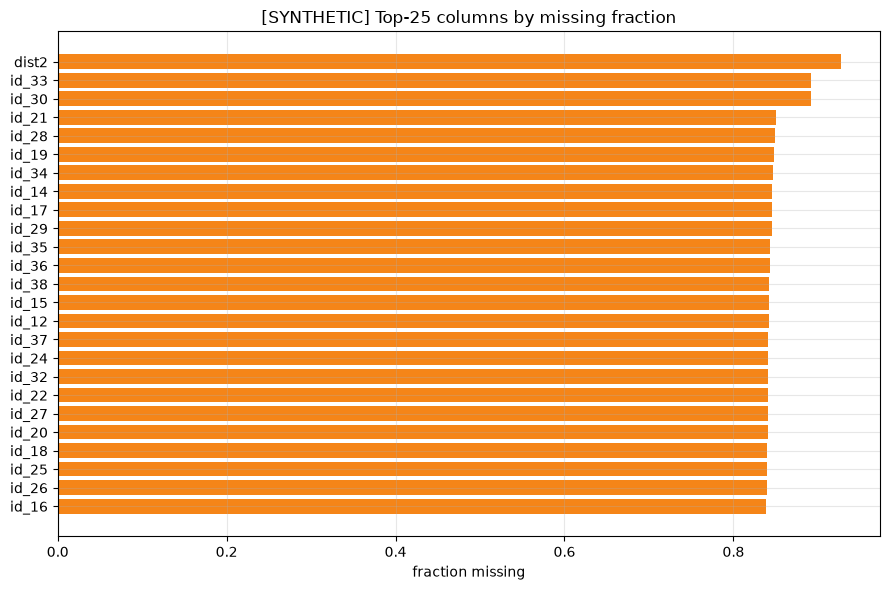

columns with any missingness: 412 / 434


,missing_frac
dist2,0.927
id_33,0.892
id_30,0.892
id_21,0.850
id_28,0.850
id_19,0.848
id_34,0.847
id_14,0.846
id_17,0.845
id_29,0.845


In [4]:
miss = df.isna().mean().sort_values(ascending=False)
top = miss[miss > 0].head(25)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index[::-1], top.values[::-1], color="#f58518")
ax.set(title=f"[{PROV}] Top-25 columns by missing fraction", xlabel="fraction missing")
plt.tight_layout()
plt.show()
print(f"columns with any missingness: {(miss > 0).sum()} / {df.shape[1]}")
top.round(3).to_frame("missing_frac").head(10)

## 4. `TransactionDT` coverage & temporal splits
The relative timestamp spans the observation window; splits are cut by time (train 60% / val 15% / holdout 25%).

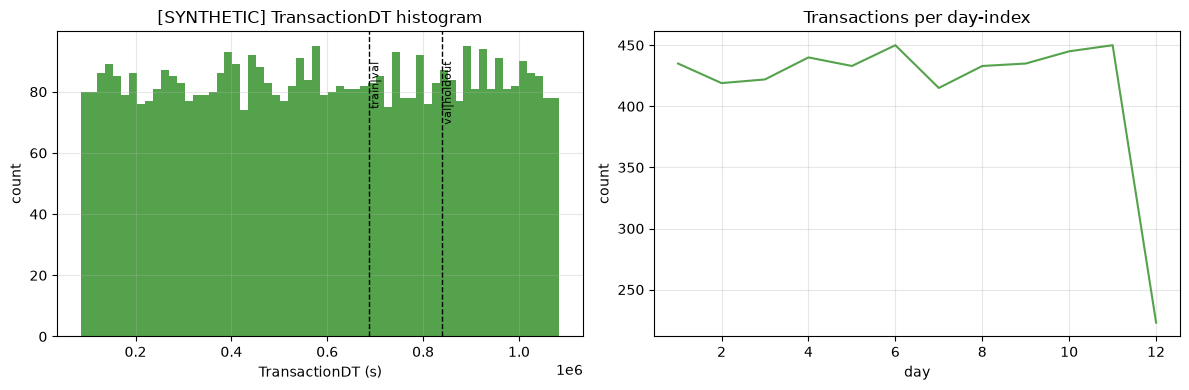

,split,rows,frac,dt_min,dt_max,fraud_rate
0,train,3000,0.60,86436,687754,0.04067
1,val,750,0.15,688065,839124,0.02400
2,holdout,1250,0.25,839357,1083726,0.02800


In [5]:
sp = data.temporal_split(features.add_base_features(df), provenance=ds.provenance)
dt = df[schema.TIME_COL]
day = dt // 86400
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dt, bins=60, color="#54a24b")
for cut, name in [(sp.cut_train_val, "train|val"), (sp.cut_val_holdout, "val|holdout")]:
    axes[0].axvline(cut, color="black", ls="--", lw=1)
    axes[0].text(cut, axes[0].get_ylim()[1] * 0.9, name, rotation=90, va="top", fontsize=8)
axes[0].set(title=f"[{PROV}] TransactionDT histogram", xlabel="TransactionDT (s)", ylabel="count")
per_day = df.groupby(day).size()
axes[1].plot(per_day.index, per_day.values, color="#54a24b")
axes[1].set(title="Transactions per day-index", xlabel="day", ylabel="count")
plt.tight_layout()
plt.show()
sp.summary()

## 5. Fraud rate over time
Stability of the base rate across the window (label drift check).

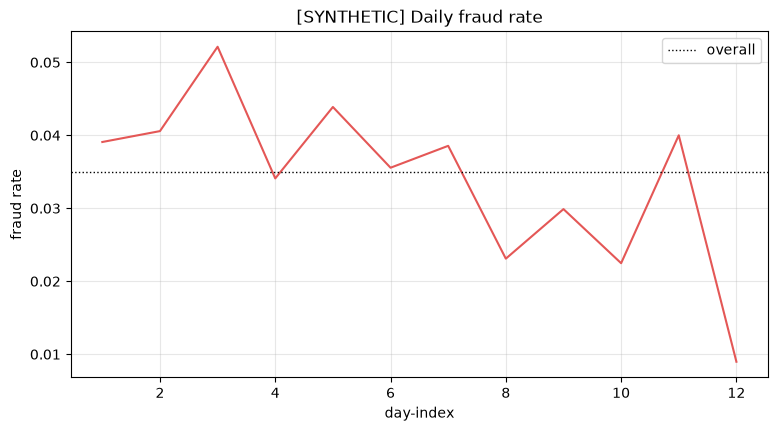

In [6]:
by_day = df.groupby(day)[schema.TARGET].mean()
fig, ax = plt.subplots()
ax.plot(by_day.index, by_day.values, color="#e45756")
ax.axhline(df[schema.TARGET].mean(), color="black", ls=":", lw=1, label="overall")
ax.set(title=f"[{PROV}] Daily fraud rate", xlabel="day-index", ylabel="fraud rate")
ax.legend()
plt.show()

## 6. Entity structure & causal features
Repeat entities (e.g. `card1`) make past-only aggregates meaningful. `prior_count` is the strictly-earlier transaction count per entity — 0 on first sighting.

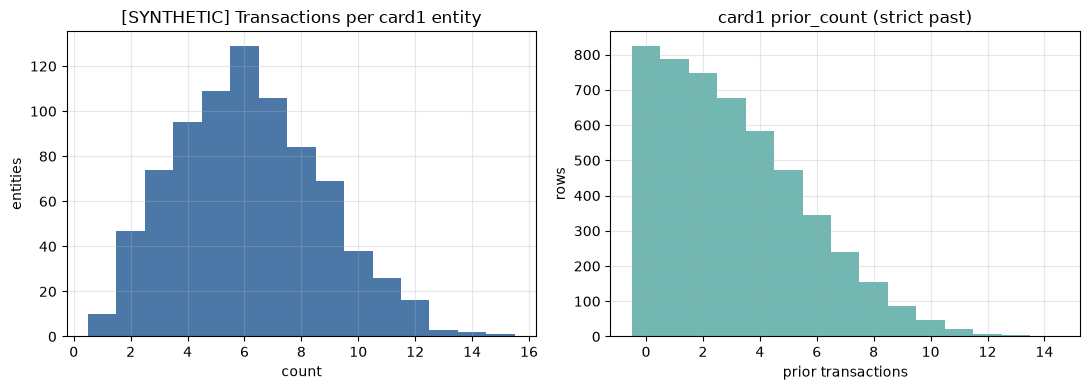

rows with >=1 prior card1 transaction: 83.5%


,ent_card1__prior_count,ent_card1__prior_amt_mean,ent_card1__prior_amt_std,ent_card1__recency
count,5000.00,4175.00,4175.00,4175.00
mean,3.12,108.42,69.56,127409.09
std,2.54,111.05,98.21,120882.97
min,0.00,4.18,0.00,115.00
25%,1.00,53.94,11.88,37997.50
50%,3.00,82.55,43.10,92005.00
75%,5.00,128.03,87.91,176166.50
max,14.00,2593.47,1176.38,947445.00


In [7]:
feat = features.build_features(df)
per_card = df.groupby("card1").size()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(per_card.values, bins=range(1, per_card.max() + 2), color="#4c78a8", align="left")
axes[0].set(title=f"[{PROV}] Transactions per card1 entity", xlabel="count", ylabel="entities")
pc = feat["ent_card1__prior_count"]
axes[1].hist(pc, bins=range(0, int(pc.max()) + 2), color="#72b7b2", align="left")
axes[1].set(title="card1 prior_count (strict past)", xlabel="prior transactions", ylabel="rows")
plt.tight_layout()
plt.show()
print(f"rows with >=1 prior card1 transaction: {(pc > 0).mean():.1%}")
feat.filter(like="ent_card1__").describe().round(2)

---
**Takeaways.** Rare-positive class → PR-AUC + cost-framed thresholds over raw accuracy. Heavy amount tails → log transforms. Block missingness → tree models tolerate NaN natively; the linear baseline needs imputation. Time-ordered window → temporal splits and strict-past aggregates (enforced by `tests/test_causality.py`).